<a href="https://colab.research.google.com/github/sathu0622/DL_Assigment/blob/feature%2Fabishek/Artificial%20Neural%20Network%20(ANN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction**

In this section, a **basic Artificial Neural Network (ANN)** model is implemented using the Fashion MNIST dataset.  
The aim is to establish a simple baseline model for comparison with more complex architectures such as CNNs and augmented networks developed by other group members.  
An ANN is a feed-forward neural network composed of multiple fully connected layers, suitable for handling flattened image data without spatial hierarchy.

# **Importing Required Libraries**

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

# **Loading and Preparing the Dataset**

In [ ]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# **Building the ANN Model**

In [ ]:
model1 = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])


# **Compiling the Model**

In [ ]:
model1.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

# **Training the Model**

In [ ]:
history1 = model1.fit(x_train, y_train, epochs=10,
                      validation_data=(x_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7788 - loss: 0.6381 - val_accuracy: 0.8550 - val_loss: 0.4005
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8636 - loss: 0.3756 - val_accuracy: 0.8639 - val_loss: 0.3752
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8767 - loss: 0.3332 - val_accuracy: 0.8643 - val_loss: 0.3712
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8832 - loss: 0.3134 - val_accuracy: 0.8631 - val_loss: 0.3750
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8929 - loss: 0.2892 - val_accuracy: 0.8743 - val_loss: 0.3529
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8974 - loss: 0.2762 - val_accuracy: 0.8814 - val_loss: 0.3334
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9031 - loss: 0.2597 - val_accuracy: 0.8665 - val_loss: 0.3727
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9036 - loss: 0.2552 - 

# **Model Evaluation**

In [ ]:
test_loss, test_acc = model1.evaluate(x_test, y_test)
print(f"\nFinal Test Accuracy (ANN): {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8780 - loss: 0.3628

Final Test Accuracy (ANN): 0.8793


# **Visualizing Accuracy**

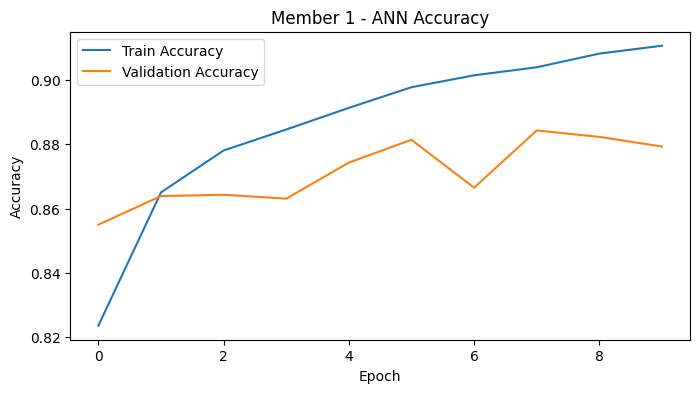

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(history1.history['accuracy'], label='Train Accuracy')
plt.plot(history1.history['val_accuracy'], label='Validation Accuracy')
plt.title("ANN Accuracy")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Visualizing Loss
plt.figure(figsize=(8,4))
plt.plot(history1.history['loss'], label='Train Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')
plt.title("ANN Loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
#Custom Prediction
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Class names from Fashion MNIST dataset
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print("\n📂 Upload a custom clothing image (JPG or PNG)...")
uploaded = files.upload()

for fname in uploaded.keys():
    # Load image and convert to grayscale
    img = Image.open(fname).convert('L').resize((28, 28))

    # Convert to numpy and normalize
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

    # Predict using the trained ANN model
    pred = model1.predict(img_array, verbose=0)
    pred_label = np.argmax(pred)
    confidence = np.max(pred) * 100

    # Display the image and prediction
    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted: {class_names[pred_label]} ({confidence:.1f}%)")
    plt.axis('off')
    plt.show()



📂 Upload a custom clothing image (JPG or PNG)...
